# Determine line spacing
Here we estimate the lines spacing for an entire survey, as well as separately calculating the line spacing and tie spacing.

In [1]:
# %load_ext autoreload
# %autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import airbornegeo

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed.csv")
data_df = data_df[["easting", "northing", "line", "unixtime"]]

# define flight lines vs tie lines
data_df["line_type"] = np.where(data_df.line >= 142, "tie", "line")

data_df

,easting,northing,line,unixtime,line_type
0,6.210722e+05,159052.962392,1,1.229500e+09,line
1,6.211260e+05,159060.533993,1,1.229500e+09,line
2,6.211797e+05,159067.801202,1,1.229500e+09,line
3,6.212333e+05,159074.801823,1,1.229500e+09,line
4,6.212870e+05,159081.682095,1,1.229500e+09,line
...,...,...,...,...,...
1060384,1.082042e+06,113004.019427,206,1.231249e+09,tie
1060385,1.082042e+06,113004.019427,206,1.231249e+09,tie
1060386,1.082042e+06,113004.019427,206,1.231249e+09,tie
1060387,1.082042e+06,113004.019427,206,1.231249e+09,tie


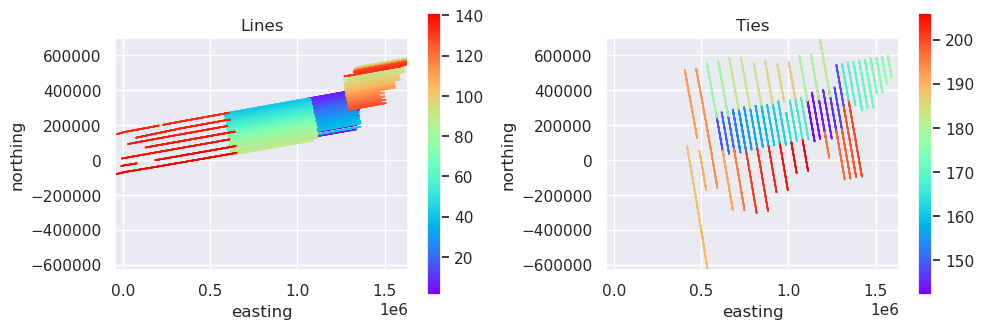

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

df = data_df[::10]
ax = df[df.line_type == "line"].plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[0],
    colorbar=False,
    title="Lines",
)
ax.set_xlim(data_df.easting.min(), data_df.easting.max())
ax.set_ylim(data_df.northing.min(), data_df.northing.max())
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

ax = df[df.line_type == "tie"].plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.02,
    cmap="rainbow",
    ax=axs[1],
    colorbar=False,
    title="Ties",
)
ax.set_xlim(data_df.easting.min(), data_df.easting.max())
ax.set_ylim(data_df.northing.min(), data_df.northing.max())
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

In [13]:
# to speed up the calculation, we can decimated the dataset
df = data_df[::10]

In [14]:
# get spacing of entire survey
survey_spacing = airbornegeo.median_line_spacing(
    df,
)
print(f"All line spacing: {survey_spacing} m")

# only supply the flight lines to get the flight line spacing
line_spacing = airbornegeo.median_line_spacing(
    df[df.line_type == "line"],
)
print(f"Flight line spacing: {line_spacing} m")

# only supply the tie lines to get the tie line spacing
tie_spacing = airbornegeo.median_line_spacing(
    df[df.line_type == "tie"],
)
print(f"Tie line spacing: {tie_spacing} m")

All line spacing: 4850.649460528189 m
Flight line spacing: 4879.472636396049 m
Tie line spacing: 33208.704726535325 m
